<a href="https://colab.research.google.com/github/jose-ll4nos/Prediccion-demanda-retail/blob/main/Modelo_de_predicci%C3%B3n_de_ventas_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. INSTALAR LIBRERÍAS


In [1]:
!pip install prophet openpyxl -q

# 2. IMPORTAR LIBRERÍAS


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 3. CARGAR DATOS DESDE EL EXCEL


In [3]:
# Lee el archivo que subiste
df = pd.read_excel('resultsfinal.xlsx')

# Verificar que los datos se cargaron bien
print("✅ Datos cargados correctamente:")
print(f"   - Filas: {len(df)}")
print(f"   - Fechas: {df['Fecha'].min()} a {df['Fecha'].max()}")
print(f"   - Categorías: {df['categoría'].unique()}")
print("\nPrimeras 5 filas:")
print(df.head())

# Prophet necesita columnas 'ds' (fecha) y 'y' (valor)
df['ds'] = pd.to_datetime(df['Fecha'])  # Aseguramos formato datetime
df['y'] = df['demandatotal']             # La demanda es nuestro objetivo

✅ Datos cargados correctamente:
   - Filas: 72
   - Fechas: 2022-01-01 00:00:00 a 2024-12-01 00:00:00
   - Categorías: ['Accesorios' 'Electrónica']

Primeras 5 filas:
     categoría  demandatotal  ingresostotales      Fecha   Año  Trimestre  \
0   Accesorios           663          22213.5 2022-01-01  2022          1   
1  Electrónica           351         213780.0 2022-01-01  2022          1   
2   Accesorios           588          19779.0 2022-02-01  2022          1   
3  Electrónica           323         211470.0 2022-02-01  2022          1   
4   Accesorios           905          32674.0 2022-03-01  2022          1   

       Mes  
0    Enero  
1    Enero  
2  Febrero  
3  Febrero  
4    Marzo  


# 4. FUNCIÓN PARA ENTRENAR Y PREDECIR POR CATEGORÍA

In [4]:
def entrenar_modelo(df, categoria):
    print(f"\n{'='*50}")
    print(f"📊 PROCESANDO: {categoria}")
    print('='*50)

    # Filtrar datos de la categoría
    df_cat = df[df['categoría'] == categoria][['ds', 'y']].copy()
    df_cat = df_cat.sort_values('ds').reset_index(drop=True)

    # Dividir en entrenamiento (2022-2023) y prueba (2024)
    # Usamos fecha límite para simular el mundo real: predecir el futuro
    train = df_cat[df_cat['ds'] < '2024-01-01']
    test = df_cat[df_cat['ds'] >= '2024-01-01']

    print(f"   - Entrenamiento: {len(train)} meses (2022-2023)")
    print(f"   - Prueba: {len(test)} meses (2024)")

    # ========== ENTRENAR MODELO PROPHET ==========
    model = Prophet(
        yearly_seasonality=True,   # Patrón anual (picos en verano/diciembre)
        weekly_seasonality=False,  # No tenemos datos semanales
        daily_seasonality=False,
        changepoint_prior_scale=0.5  # Flexibilidad para cambios de tendencia
    )
    model.fit(train)

    # ========== PREDECIR 2024 (VALIDACIÓN) ==========
    # Creamos un dataframe con las fechas del periodo de prueba
    future_test = pd.DataFrame({'ds': test['ds']})
    forecast_test = model.predict(future_test)

    # ========== EVALUAR ERRORES ==========
    # Unimos las predicciones con los valores reales
    test_pred = forecast_test.set_index('ds')['yhat'].loc[test['ds']]
    mae = mean_absolute_error(test['y'], test_pred)
    rmse = np.sqrt(mean_squared_error(test['y'], test_pred))
    mape = np.mean(np.abs((test['y'] - test_pred) / test['y'])) * 100

    print(f"\n   📈 MÉTRICAS DE VALIDACIÓN 2024:")
    print(f"   - Error Absoluto Medio (MAE): {mae:.2f} unidades")
    print(f"   - Raíz del Error Cuadrático (RMSE): {rmse:.2f} unidades")
    print(f"   - Error Porcentual Absoluto (MAPE): {mape:.2f}%")

    # ========== PREDECIR 2025 (FUTURO) ==========
    # Predecir los próximos 12 meses
    future = model.make_future_dataframe(periods=12, freq='MS')  # MS = Mes Inicio
    forecast = model.predict(future)

    # ========== GRÁFICOS ==========
    # Gráfico 1: Histórico + Predicción con intervalo de confianza
    fig1 = model.plot(forecast)
    plt.title(f'Predicción de Demanda - {categoria}', fontsize=14)
    plt.xlabel('Fecha')
    plt.ylabel('Demanda (unidades)')
    plt.axvline(x=pd.Timestamp('2024-01-01'), color='red', linestyle='--', label='Inicio Predicción')
    plt.legend()
    plt.show()

    # Gráfico 2: Componentes (Tendencia y Estacionalidad)
    fig2 = model.plot_components(forecast)
    plt.show()

    # ========== GUARDAR PREDICCIONES ==========
    # Guardamos solo las columnas relevantes para Power BI
    output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    output['categoria'] = categoria
    output.to_csv(f'prediccion_{categoria}.csv', index=False)
    print(f"   ✅ Predicciones guardadas en 'prediccion_{categoria}.csv'")

    return model, forecast, test

# 5. EJECUTAR EL MODELO PARA CADA CATEGORÍA



📊 PROCESANDO: Accesorios
   - Entrenamiento: 24 meses (2022-2023)
   - Prueba: 12 meses (2024)


INFO:prophet:n_changepoints greater than number of observations. Using 18.



   📈 MÉTRICAS DE VALIDACIÓN 2024:
   - Error Absoluto Medio (MAE): 382.51 unidades
   - Raíz del Error Cuadrático (RMSE): 490.07 unidades
   - Error Porcentual Absoluto (MAPE): nan%


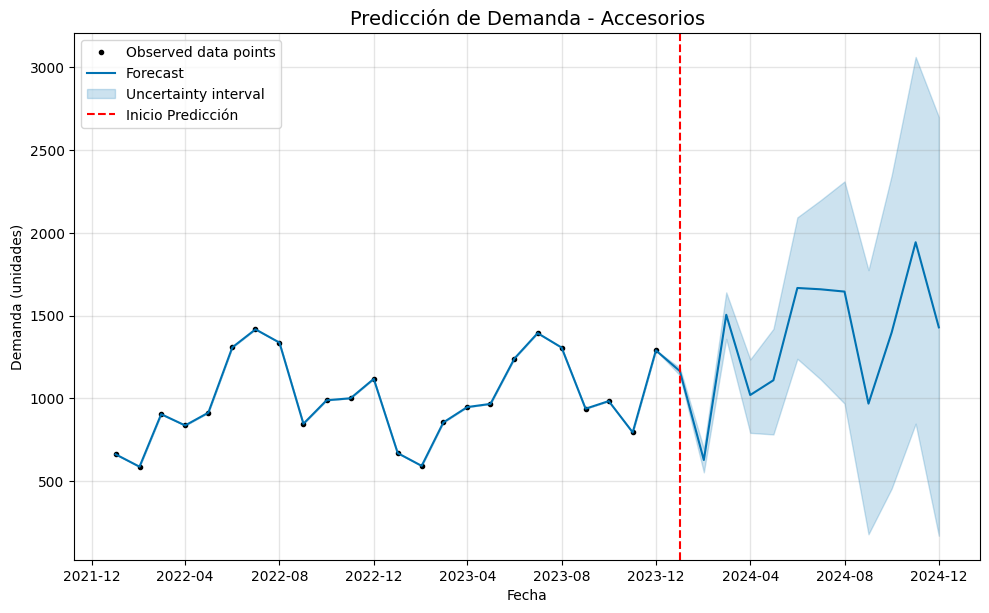

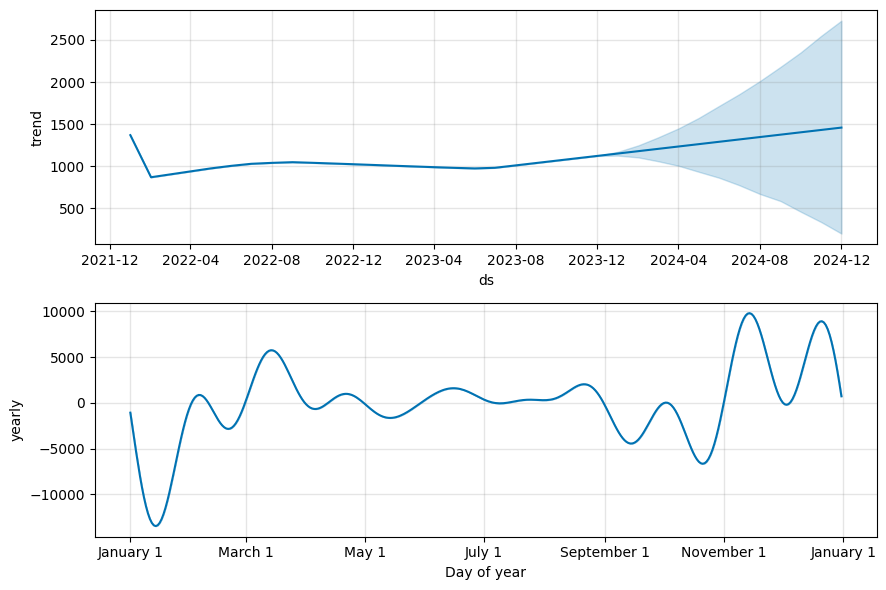

INFO:prophet:n_changepoints greater than number of observations. Using 18.


   ✅ Predicciones guardadas en 'prediccion_Accesorios.csv'

📊 PROCESANDO: Electrónica
   - Entrenamiento: 24 meses (2022-2023)
   - Prueba: 12 meses (2024)

   📈 MÉTRICAS DE VALIDACIÓN 2024:
   - Error Absoluto Medio (MAE): 139.31 unidades
   - Raíz del Error Cuadrático (RMSE): 156.94 unidades
   - Error Porcentual Absoluto (MAPE): nan%


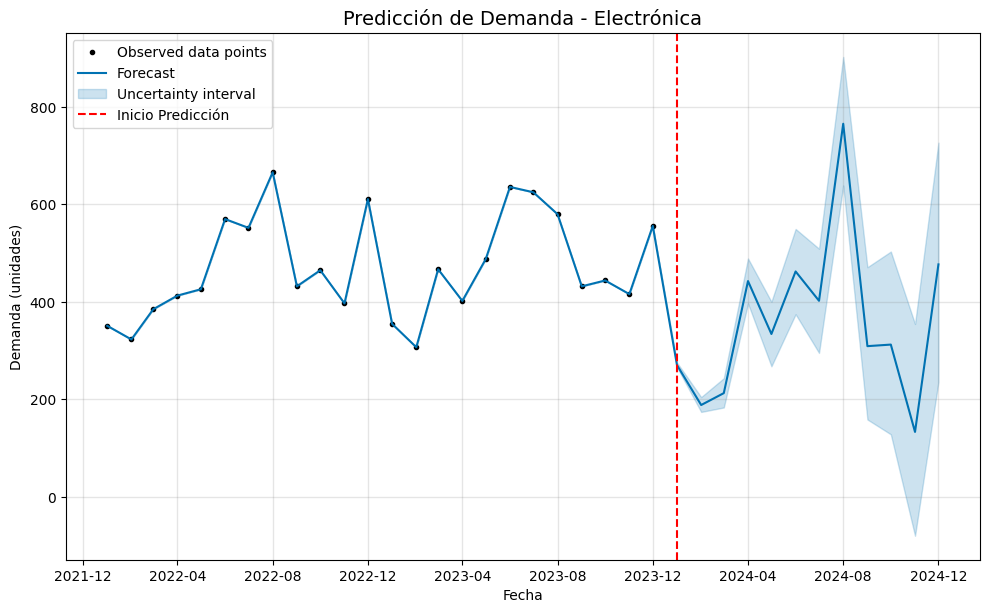

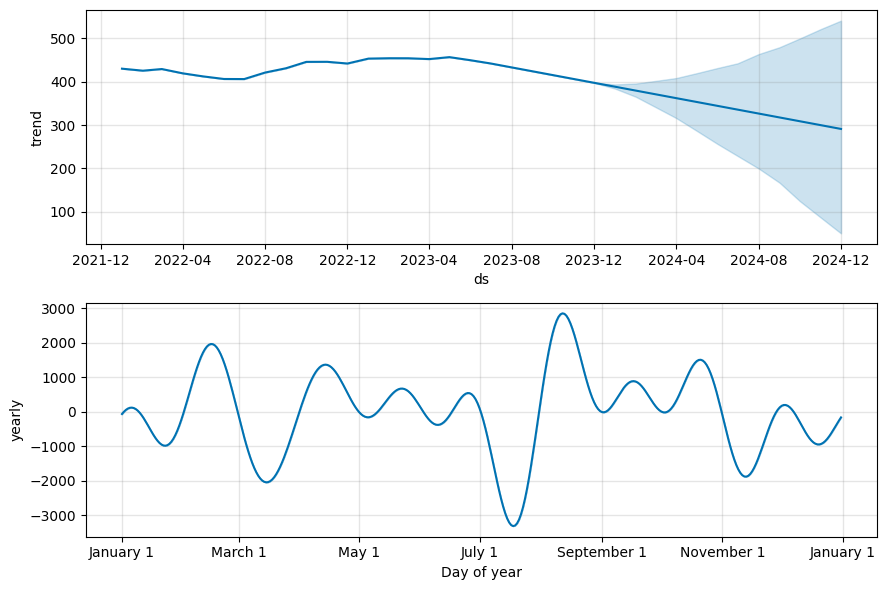

   ✅ Predicciones guardadas en 'prediccion_Electrónica.csv'

🎉 ¡FASE 3 COMPLETADA!
   - Archivos CSV generados para Power BI.
   - Métricas de error calculadas.


In [5]:
modelos = {}
for cat in df['categoría'].unique():
    modelos[cat], forecast, test = entrenar_modelo(df, cat)

print("\n" + "="*50)
print("🎉 ¡FASE 3 COMPLETADA!")
print("   - Archivos CSV generados para Power BI.")
print("   - Métricas de error calculadas.")
print("="*50)